In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pickle

plt.style.use(['science','notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']

In [2]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

Read data

In [6]:
Ns = np.append([100, 200], np.arange(500,5500,500))
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(Ns),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(Ns),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(Ns),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(Ns),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(Ns)))
egc_index_Y_to_X = np.zeros((nseeds,len(Ns)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/rossler_diff/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(Ns)))
L_Y_to_X = np.zeros((nseeds,len(Ns)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/rossler_diff/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(Ns)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(Ns))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"./transfer_entropy/pickles/rossler_diff/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])


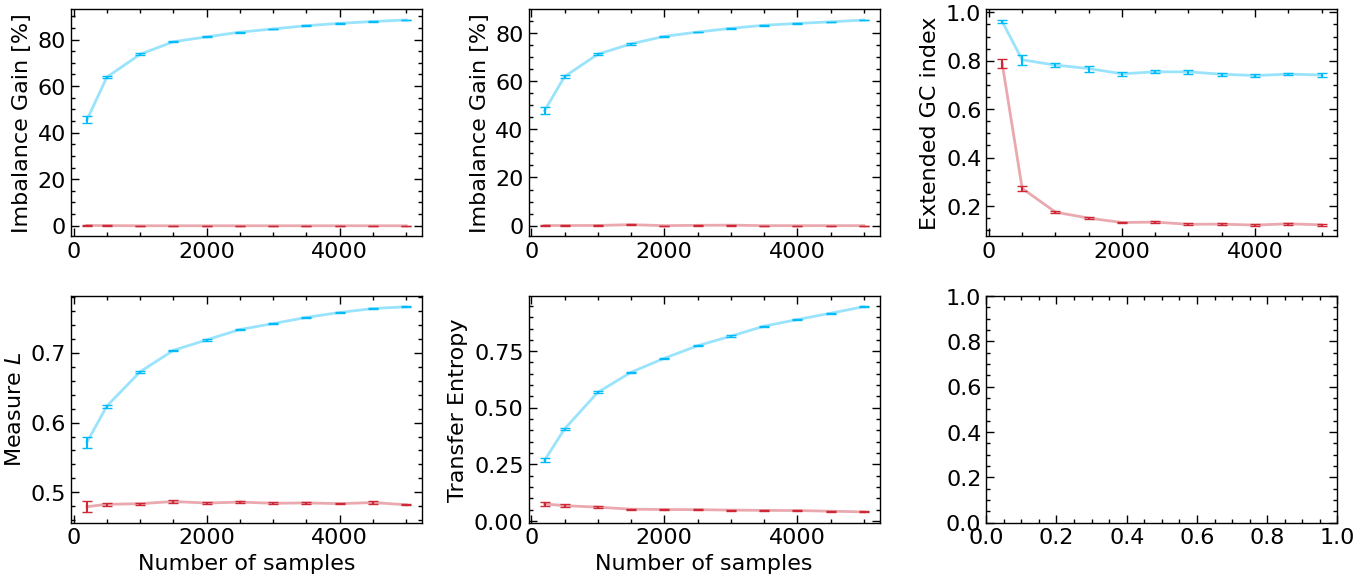

In [26]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,3,figsize=(14,6))
fig.tight_layout()

start_N = 1

ax[0,0].errorbar(Ns[start_N:], IGs_X_to_Y[start_N:], IGs_X_to_Y_err[start_N:], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,0].errorbar(Ns[start_N:], IGs_Y_to_X[start_N:], IGs_Y_to_X_err[start_N:], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,0].plot(Ns[start_N:], IGs_X_to_Y[start_N:], '-', color=colors[0], label="$X\\rightarrow Y$", alpha=0.4)
ax[0,0].plot(Ns[start_N:], IGs_Y_to_X[start_N:], '-', color=colors[1], label="$Y\\rightarrow X$", alpha=0.4)
ax[0,0].set(xlabel="Number of samples", ylabel="Imbalance Gain [%]")
#ax[0,0].legend()

ax[0,1].errorbar(Ns[start_N:], IGs_X_to_Y_emb[start_N:], IGs_X_to_Y_err_emb[start_N:], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,1].errorbar(Ns[start_N:], IGs_Y_to_X_emb[start_N:], IGs_Y_to_X_err_emb[start_N:], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,1].plot(Ns[start_N:], IGs_X_to_Y_emb[start_N:], '-', color=colors[0], label="$X\\rightarrow Y$", alpha=0.4)
ax[0,1].plot(Ns[start_N:], IGs_Y_to_X_emb[start_N:], '-', color=colors[1], label="$Y\\rightarrow X$", alpha=0.4)
ax[0,1].set(xlabel="Number of samples", ylabel="Imbalance Gain [%]")
#ax.legend()

ax[0,2].errorbar(Ns[start_N:], egc_index_X_to_Y_avg[start_N:], egc_index_X_to_Y_err[start_N:], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,2].errorbar(Ns[start_N:], egc_index_Y_to_X_avg[start_N:], egc_index_Y_to_X_err[start_N:], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0,2].plot(Ns[start_N:], egc_index_X_to_Y_avg[start_N:], '-', color=colors[0], label="$X\\rightarrow Y$", alpha=0.4)
ax[0,2].plot(Ns[start_N:], egc_index_Y_to_X_avg[start_N:], '-', color=colors[1], label="$Y\\rightarrow X$", alpha=0.4)
ax[0,2].set(xlabel="Number of samples", ylabel="Extended GC index")
#ax.legend()

ax[1,0].errorbar(Ns[start_N:], L_X_to_Y_avg[start_N:], L_X_to_Y_err[start_N:], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,0].errorbar(Ns[start_N:], L_Y_to_X_avg[start_N:], L_Y_to_X_err[start_N:], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,0].plot(Ns[start_N:], L_X_to_Y_avg[start_N:], '-', color=colors[0], label="$X\\rightarrow Y$", alpha=0.4)
ax[1,0].plot(Ns[start_N:], L_Y_to_X_avg[start_N:], '-', color=colors[1], label="$Y\\rightarrow X$", alpha=0.4)
ax[1,0].set(xlabel="Number of samples", ylabel="Measure $L$")
#ax.legend()

ax[1,1].errorbar(Ns[start_N:], TE_mean_X_to_Y_emb[start_N:], TE_err_X_to_Y_emb[start_N:], fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,1].errorbar(Ns[start_N:], TE_mean_Y_to_X_emb[start_N:], TE_err_Y_to_X_emb[start_N:], fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1,1].plot(Ns[start_N:], TE_mean_X_to_Y_emb[start_N:], '-', color=colors[0], label="$X\\rightarrow Y$", alpha=0.4)
ax[1,1].plot(Ns[start_N:], TE_mean_Y_to_X_emb[start_N:], '-', color=colors[1], label="$Y\\rightarrow X$", alpha=0.4)
ax[1,1].set(xlabel="Number of samples", ylabel="Transfer Entropy")
#ax.legend()
plt.savefig("./figures/measures_vs_N.pdf", dpi=300)
plt.show()

In [27]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression(fit_intercept=False)
xs = (1/np.sqrt(Ns)).reshape(-1, 1)


# X->Y regression
regressor.fit(xs, errs_X_to_Y)
preds_X_to_Y = regressor.predict(xs)

# Y->X regression
regressor.fit(xs, errs_Y_to_X.reshape(-1, 1))
preds_Y_to_X = regressor.predict(xs)

# Regressor coefficients and intercept
print(f'Coefficient: {regressor.coef_}')
print(f'Intercept: {regressor.intercept_}')

Coefficient: [[5.60845065]]
Intercept: 0.0


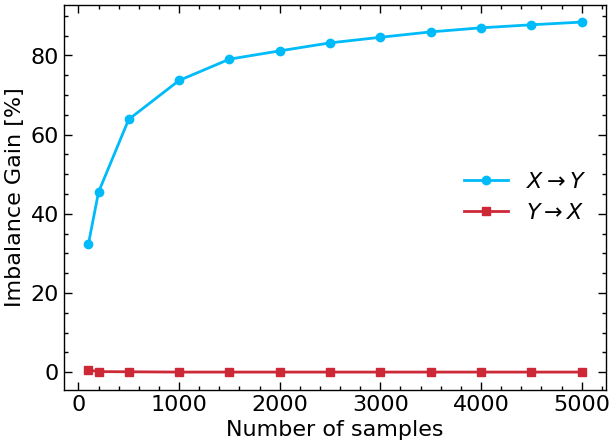

In [14]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(Ns, IGs_X_to_Y, 'o-', color=colors[0], label="$X\\rightarrow Y$")
ax.plot(Ns, IGs_Y_to_X, 's-', color=colors[1], label="$Y\\rightarrow X$")
ax.set(xlabel="Number of samples", ylabel="Imbalance Gain [%]")
ax.legend()
plt.show()

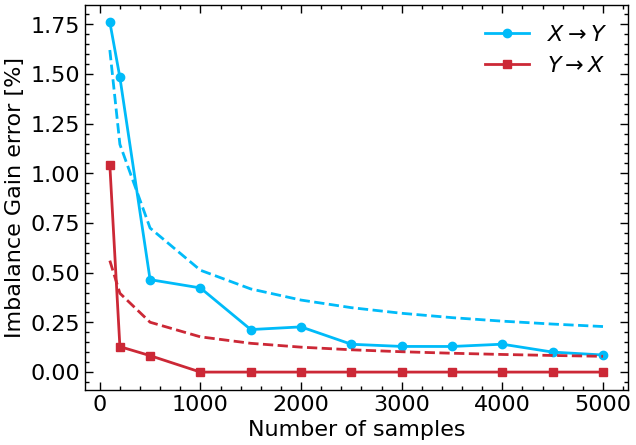

In [28]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(Ns, errs_X_to_Y, 'o-', color=colors[0], label="$X\\rightarrow Y$")
ax.plot(Ns, errs_Y_to_X, 's-', color=colors[1], label="$Y\\rightarrow X$")
ax.plot(Ns, preds_X_to_Y, '--', color=colors[0])
ax.plot(Ns, preds_Y_to_X, '--', color=colors[1])
ax.set(xlabel="Number of samples", ylabel="Imbalance Gain error [%]")
ax.legend()
plt.show()